In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [21]:
data = pd.read_csv("Iris.csv")
X = data.drop(columns=['Species'])  #  Species is the target column
y = data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Accuracy: 0.89

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       0.84      1.00      0.91        16
Iris-versicolor       0.85      0.85      0.85        13
 Iris-virginica       1.00      0.81      0.90        16

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90      0.89      0.89        45


Confusion Matrix:
[[16  0  0]
 [ 2 11  0]
 [ 1  2 13]]


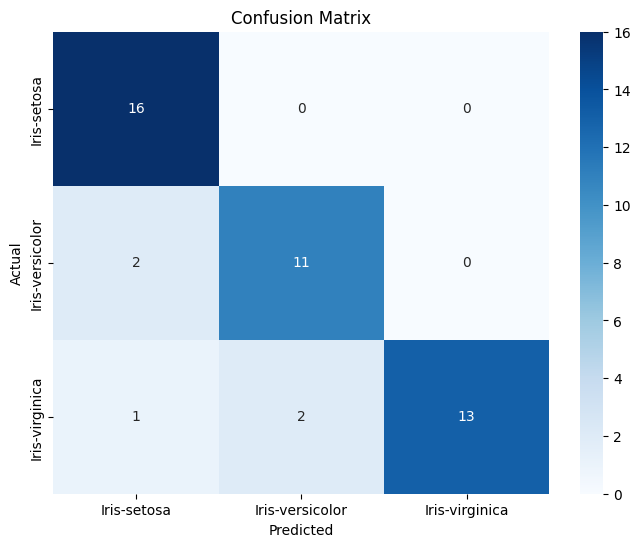

In [22]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)


y_pred = gnb.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=y.unique()))

recall = recall_score(y_test, y_pred, average='weighted') 

f1 = f1_score(y_test, y_pred, average='weighted')   
# F1 score = 2*precision*recall_score/(precison+ recall)


conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=y.unique(), yticklabels=y.unique())

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

f:\Personal\Data Science\AI-ML\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


SVM Accuracy: 0.9
ANN Accuracy: 0.8333333333333334
Naïve Bayes Accuracy: 0.9

SVM Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       0.90      1.00      0.95         9
Iris-versicolor       0.78      1.00      0.88         7
 Iris-virginica       1.00      0.79      0.88        14

       accuracy                           0.90        30
      macro avg       0.89      0.93      0.90        30
   weighted avg       0.92      0.90      0.90        30


ANN Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       0.88      0.78      0.82         9
Iris-versicolor       0.78      1.00      0.88         7
 Iris-virginica       0.85      0.79      0.81        14

       accuracy                           0.83        30
      macro avg       0.83      0.85      0.84        30
   weighted avg       0.84      0.83      0.83        30


Naïve Bayes Classification Report:
                  precisi

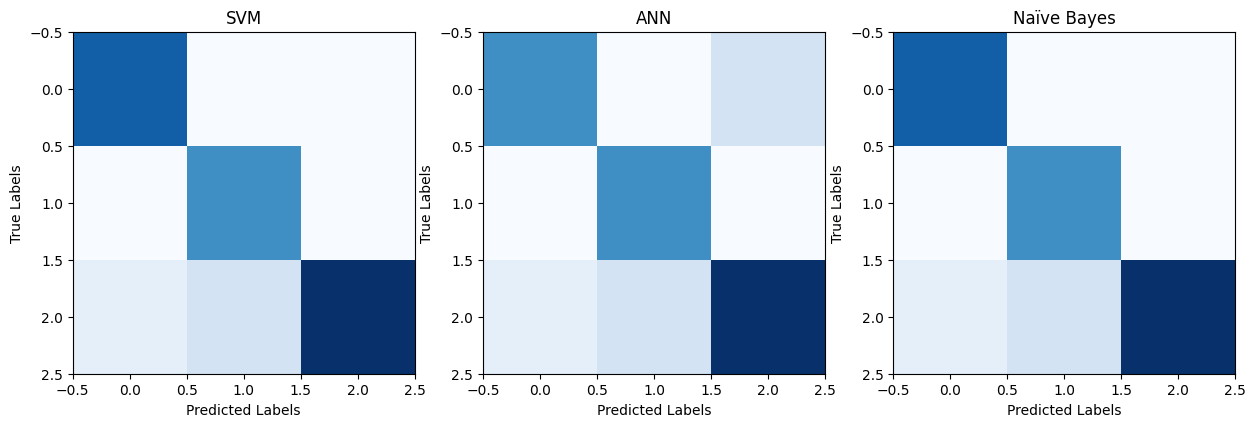

In [23]:
X = data.drop(columns=['Species'])  #  Species is the target column
y = data['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)


ann_model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)

 
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\nANN Classification Report:\n", classification_report(y_test, y_pred_ann))
print("\nNaïve Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, y_pred, title in zip(axes, [y_pred_svm, y_pred_ann, y_pred_nb], ['SVM', 'ANN', 'Naïve Bayes']):
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
plt.show()

